In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, 
confusion_matrix, classification_report)

import skfuzzy as fuzz
import itertools

import joblib

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.shape

(768, 9)

In [7]:
df[['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']].describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction
count,768.000000,768.000000,768.000000,768.000000
mean,120.894531,31.992578,33.240885,0.471876
std,31.972618,7.884160,11.760232,0.331329
min,0.000000,0.000000,21.000000,0.078000
25%,99.000000,27.300000,24.000000,0.243750
50%,117.000000,32.000000,29.000000,0.372500
75%,140.250000,36.600000,41.000000,0.626250
max,199.000000,67.100000,81.000000,2.420000


## Visualisasi awal target + fitur

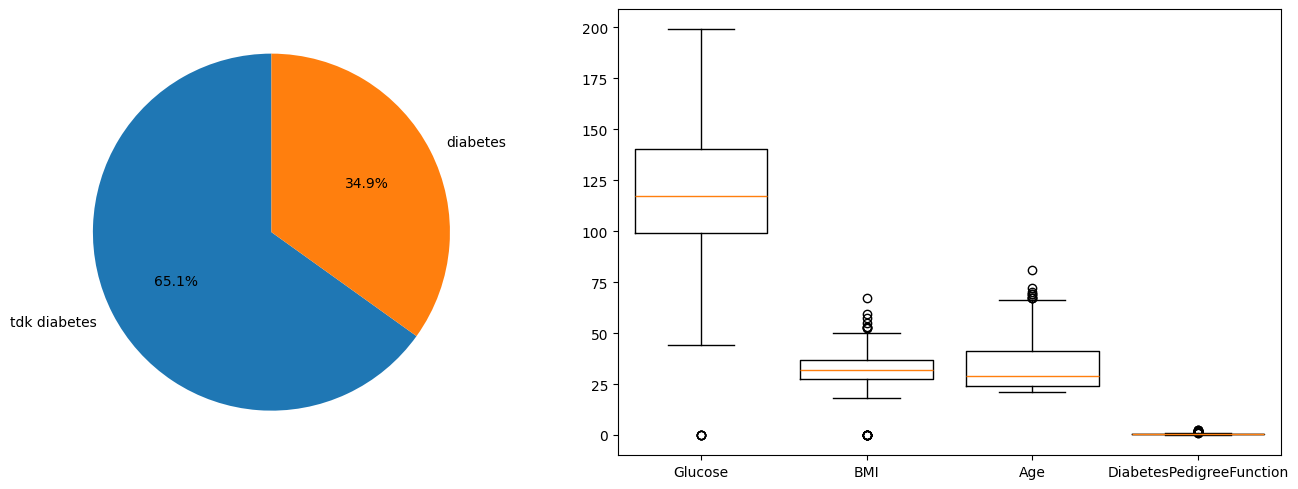

In [8]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
pie_count = df['Outcome'].value_counts()
axes[0].pie(pie_count, labels=['tdk diabetes', 'diabetes'], autopct='%1.1f%%', startangle=90)

# boxplot 4 fitur utama (Glucose, BMI, Age dan DiabetesPedigreeFunction)
boxplot1 = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
axes[1].boxplot(data=df, x=df[boxplot1], tick_labels=boxplot1, widths=0.8)

plt.tight_layout()
plt.show()

- dari dataset banyak mayoritas data pada yang tidak mengalami diabetes dengan proporsi niali 65.1% dan yang diabetes 34.9% (agak imbalance)
- Boxplot = terlihat kalau pada glucose dan BMI punya niali 0 jadi tidak realistis di dunia nyata dan harus melakukan imputasi(penghapusan missing value), utk DiabetesPedigreeFunction nilainya hanya 0-1 saja (mungkin dalam persen)

In [9]:
print(len(df[df['Glucose']==0]))
print(len(df[df['BMI']==0]))

5
11


In [10]:
# Penghapusan missing value karena hanya 16 baris aja atau sekitar 2% jadi aman
df = df[(df['Glucose'] != 0) & (df['BMI'] != 0)]

# Split data

In [11]:
fitur = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
X = df[fitur].values
y = df['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisasi menggunakan MinMaxScaler

In [12]:
scaler = MinMaxScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

# menyimpan object scaler yg sudha di latih
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [13]:
# cek statistika nilai setealh scaler
X_scaler_vis = scaler.transform(X)
df_scaled = pd.DataFrame(X_scaler_vis, columns=fitur)

df_scaled.describe()

,Glucose,BMI,Age,DiabetesPedigreeFunction
count,752.000000,752.000000,752.000000,752.000000
mean,0.506114,0.291506,0.205208,0.166546
std,0.198709,0.141696,0.195157,0.141313
min,0.000000,0.000000,0.000000,-0.002568
25%,0.362013,0.190184,0.050000,0.068493
50%,0.474026,0.288344,0.133333,0.125428
75%,0.629870,0.376278,0.333333,0.232663
max,1.006494,1.000000,1.000000,1.000000


# ANFIS LAYER 1

- Pada tahap ini akan mendifinisikan kategory fuzzy(membership function) seperti `low / medium / high` yg sudah di normalisai

## Membuat paramter MF berbasis sumber valid

In [14]:
# rentang nilai continue utk plot membership function fuzzy
x_universe = np.linspace(0, 1, 500)

# kita buat dlm dictionary
mf_param = {
    'Glucose': { # dari diabetes.org/about-diabetes/diagnosis (American Diabetes Association)
        'Low'    : (0.20, 0.15),
        'Medium' : (0.50, 0.18),
        'High'   : (0.80, 0.15),
    },
    'BMI' : { # who.int/news-room/fact-sheets/detail/obesity-and-overweight(WHO)
        'Low'    : (0.15, 0.12),
        'Medium' : (0.40, 0.18),
        'High'   : (0.70, 0.18),
    },
    'Age' : { # berdasarkan nilai stastitika
        'Low'    : (0.15, 0.18),
        'Medium' : (0.45, 0.22),
        'High'   : (0.80, 0.18),
    },
    'DiabetesPedigreeFunction' : { # berdasarkan nilai stastitika
        'Low'    : (0.10, 0.12),
        'Medium' : (0.35, 0.20),
        'High'   : (0.70, 0.20),
    },
}

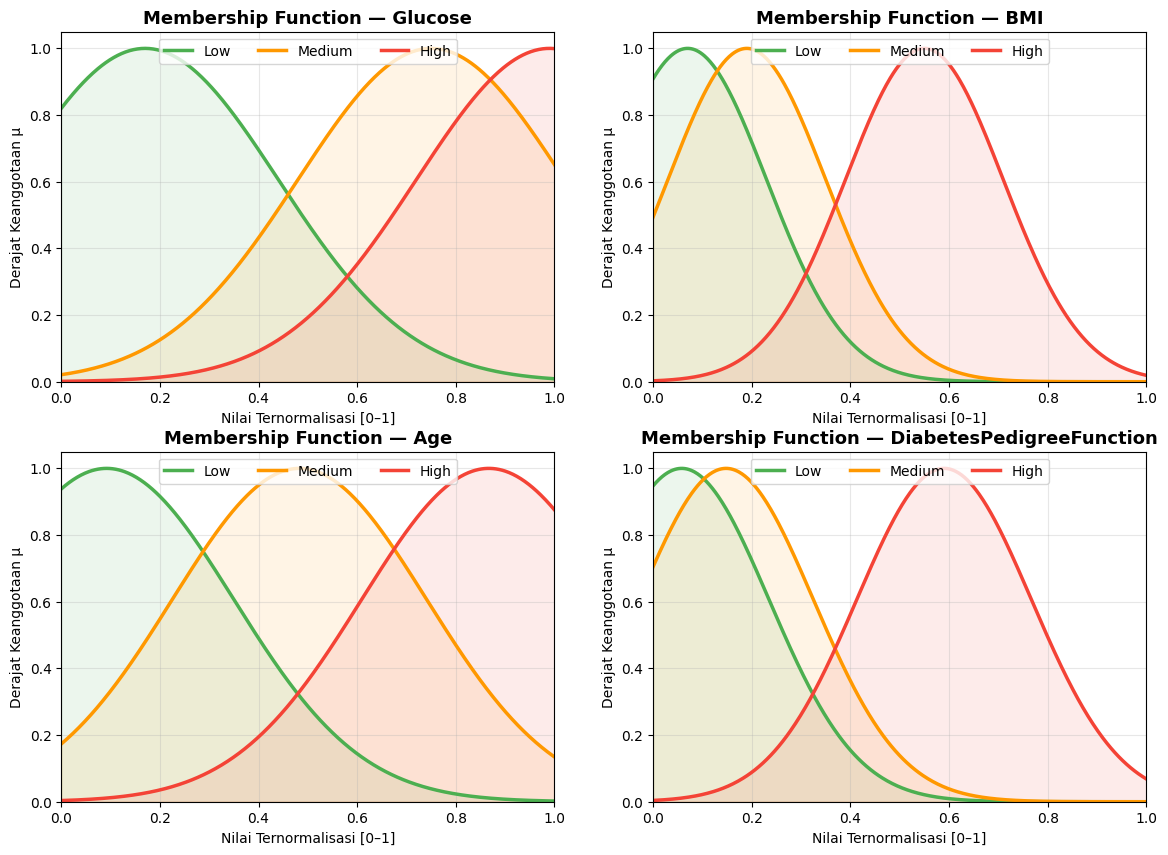

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
MF_COLORS = {'Low': '#4CAF50', 'Medium': '#FF9800', 'High': '#F44336'}

for idx, feat in enumerate(fitur):
    ax = axes[idx]
    for label, (center, sigma) in mf_param[feat].items():
        mf_vals = fuzz.gaussmf(x_universe, center, sigma)
        ax.plot(x_universe, mf_vals, label=label,
                color=MF_COLORS[label], linewidth=2.5)
        ax.fill_between(x_universe, mf_vals, alpha=0.10, color=MF_COLORS[label])
    ax.set_title(f'Membership Function — {feat}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Nilai Ternormalisasi [0–1]')
    ax.set_ylabel('Derajat Keanggotaan μ')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
    ax.legend(loc='upper center', ncol=3, fontsize=10)
    ax.grid(True, alpha=0.3)

# Implementasi Algoritma Anfis

In [ ]:
# class blueprint ANFIS
class ANFIS:
    def __init__(self, n_mf=3, epochs=200, lr_premise=0.005,
                 l2_lambda=1e-4, patience=30):
        self.n_mf        = n_mf
        self.epochs      = epochs
        self.lr_premise  = lr_premise
        self.lr          = lr_premise
        self.l2_lambda   = l2_lambda
        self.patience    = patience
        self.tolerance   = 1e-4
        self.loss_hist   = []
        self._is_fitted  = False

# layer 1 Function Membership (utk menghitung fuzzy membership) --> gausian mf
    def _gaussmf(self, x, c, sigma):
        return np.exp(-0.5 * ((x - c) / (sigma + 1e-8)) ** 2) # rumus gaussian mf

# layer 2 Product (T-norm) (utk menghitung seberapa kuat dari kombinasi role yg ada)
    def _rule_strength(self, mu):
        # inputan nantinya mu: (n_samples, n_inputs, n_mf) → (n_samples, n_rules)
        n = mu.shape[0]
        strengths = np.ones((n, self.n_rules))
        for r, combo in enumerate(self.rule_combos):
            mu_stack = np.stack(
                [mu[:, i, mf_idx] for i, mf_idx in enumerate(combo)],
                axis=1)
            strengths[:, r] = mu_stack.min(axis=1)
        return strengths

# layer 3 Normalisasi -> mengubah hasil role tdi mejadi bobot relatif (kontribusi)
    def _normalize(self, strengths):
        total = strengths.sum(axis=1, keepdims=True) + 1e-8
        return strengths / total
 
# layer 4 dan 5 (Consequent & Output)
    def _output(self, X_aug, w_norm):
        consequents = X_aug @ self.C.T
        return (w_norm * consequents).sum(axis=1)

# --------> FORWARD PASS -------------
    def _forward(self, X):
        n_samples, n_inputs = X.shape
        # utk layer 1
        mu = np.zeros((n_samples, n_inputs, self.n_mf)) # membuat wadah kosong
        for i in range (n_inputs):
            for k in range(self.n_mf):
                mu[:, i, k] = self._gaussmf(X[:, i], self.centers[i,k], self.sigmas[i,k])

        # utk layer 2 
        strengths = self._rule_strength(mu)

        # utk layer 3
        w_norm = self._normalize(strengths)

        # utk layer 4 & 5
        X_aug = np.hstack([X, np.ones((n_samples, 1))]) # consequent Sugeno linear punya nilai bias
        output = self._output (X_aug, w_norm) # Consequent Sugeno linear
        return output, w_norm, strengths, mu

# --------> FIT -------------
    def fit(self, X, y):
        n_samples, n_inputs = X.shape
        self.n_inputs = n_inputs

        # kita generate semua kombinasi rule 
        self.rule_combos = list(itertools.product(range(self.n_mf), repeat=n_inputs))
        self.n_rules = len(self.rule_combos)

        # center dan sigmanya berdasarkan nilai pada dictionary yang sudah di tentukan
        labels = ['Low', 'Medium', 'High']

        # utk center
        self.centers = np.array([
            [mf_param[feat][lbl][0] for lbl in labels] 
            for feat in fitur 
        ])

        # utk sigma 
        self.sigmas = np.array([
            [mf_param[feat][lbl][1] for lbl in labels]
            for feat in fitur
        ])

        # random nilai self.C (utk dipakai di output pada  linear sugeno)
        rng = np.random.RandomState(42)

        self.C = rng.randn(self.n_rules, n_inputs + 1) * 0.5 # kali 0.5 biar bobot awal g gede
        self.C[:, -1] = rng.uniform(0.2, 0.8, self.n_rules)
        print(f"Input     : {n_inputs} fitur")
        print(f"MF/fitur  : {self.n_mf}")
        print(f"Rules     : {self.n_rules}")
        print(f"Epochs    : {self.epochs}")
        print(f"LR        : {self.lr}")
        print("-" * 50)

        for epoch in range(self.epochs):
            # masuk ke fungsi Forward dan ambil hasilnya
            output, w_norm, strengths, mu = self._forward(X)
            output_clipped = np.clip(output, 0,1) # batasi hasil dari proses output menjadi 0 - 1

            # menghitung loss model
            eps = 0.00000001 # agar menghindari nilai 0 (takut error)
            # bagian ini kita anggap false negative atau kelas minoritas berbahaya jadi diberi
            # loss sebanyak --> pos_weight x lossnya
            pos_weight = (y == 0).sum()/(y == 1).sum()
            bce = -np.mean(
                pos_weight*y*np.log(output_clipped + eps ) + # kelas positif (1)
                (1 - y) * np.log(1 - output_clipped + eps) # kelas negatif (0)
            )

            # total loss
            l2 = 0.0001 * np.sum(self.C**2)
            loss = bce + l2
            self.loss_hist.append(loss)

            # Backward: (update consequent self.C) dari kesalahan prediksi model
            delta = output_clipped - y
            X_aug = np.hstack([X, np.ones((n_samples, 1))])
            dC = (w_norm.T @ (delta[:, None] * X_aug)) / n_samples
            self.C -= self.lr * dC

            # Early stopping
            if epoch > self.patience and abs(self.loss_hist[-2] - loss) < self.tolerance and loss < 0.5:
                print(f"Early stopping pada epoch {epoch+1} (loss konvergen)")
                break

            # monitoring loss 
            if (epoch + 1) % 20 == 0 or epoch == 0:
                y_pred = (output_clipped >= 0.5).astype(int)
                acc = accuracy_score(y, y_pred)
                print(f"Epoch [{epoch+1:>4}/{self.epochs}]  "
                      f"Loss: {loss:.5f}  Acc: {acc:.4f}")

        self._is_fitted = True # utk di gass :v
        print("-" * 50)
        print("Done wak.")
        return self
        
    # prediksi dalam probalitas 
    def predict_proba(self, X):
        assert self._is_fitted, 'error wak' # pastikan self._is_fitted True
        output, _, _, _ = self._forward(X)
        return np.clip(output, 0, 1)

    # prediksi 
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    # Membuat derajat keanggotaan untuk interpretabilitas
    def get_membership(self, x_single):
        result = {}
        labels = ['Low', 'Medium', 'High']
        for i, feat in enumerate(fitur):
            result[feat] = {}
            for k, lbl in enumerate(labels):
                result[feat][lbl] = float(
                    self._gaussmf(x_single[i], self.centers[i, k], self.sigmas[i, k])
                )
        return result

In [17]:
anfis = ANFIS()
# kasih inputan ke subclass fit
anfis.fit(X_train, y_train)

Input     : 4 fitur
MF/fitur  : 3
Rules     : 81
Epochs    : 200
LR        : 0.01
--------------------------------------------------
Epoch [   1/200]  Loss: 11.96248  Acc: 0.6489
Epoch [  20/200]  Loss: 11.96248  Acc: 0.6489
Epoch [  40/200]  Loss: 11.96248  Acc: 0.6489
Epoch [  60/200]  Loss: 11.96248  Acc: 0.6489
Epoch [  80/200]  Loss: 11.96248  Acc: 0.6489
Epoch [ 100/200]  Loss: 11.96248  Acc: 0.6489
Epoch [ 120/200]  Loss: 11.96248  Acc: 0.6489
Epoch [ 140/200]  Loss: 11.96248  Acc: 0.6489
Epoch [ 160/200]  Loss: 11.96248  Acc: 0.6489
Epoch [ 180/200]  Loss: 11.96248  Acc: 0.6489
Epoch [ 200/200]  Loss: 11.96248  Acc: 0.6489
--------------------------------------------------
Done wak.
